In [146]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### 1. Concatenando as bases de dados

In [147]:
df_2024_1 = pd.read_csv('dados/2024_1.csv', sep=';', decimal=',')
df_2024_2 = pd.read_csv('dados/2024_2.csv', sep=';', decimal=',')
df_2025_1 = pd.read_csv('dados/2025_1.csv', sep=';', decimal=',')
df_2025_2 = pd.read_csv('dados/2025_2.csv', sep=';', decimal=',')
df = pd.concat([df_2024_1, df_2024_2,df_2025_1, df_2025_2], ignore_index=True)

C:\Users\ian.iannacconi.SENACRJEDU.000\AppData\Local\Temp\ipykernel_10552\2790895961.py:3: DtypeWarning: Columns (0: Regiao - Sigla, 1: Estado - Sigla, 2: Municipio, 3: Revenda, 4: CNPJ da Revenda, 5: Nome da Rua, 6: Numero Rua, 7: Complemento, 8: Bairro, 9: Cep, 10: Produto, 11: Data da Coleta, 12: Unidade de Medida, 13: Bandeira) have mixed types. Specify dtype option on import or set low_memory=False.
  df_2025_1 = pd.read_csv('dados/2025_1.csv', sep=';', decimal=',')


In [148]:
df.columns

Index(['Regiao - Sigla', 'Estado - Sigla', 'Municipio', 'Revenda',
       'CNPJ da Revenda', 'Nome da Rua', 'Numero Rua', 'Complemento', 'Bairro',
       'Cep', 'Produto', 'Data da Coleta', 'Valor de Venda', 'Valor de Compra',
       'Unidade de Medida', 'Bandeira'],
      dtype='str')

### 2. Preço médio da gasolina c no estado do RJ por municipio

In [149]:
df_comun = df.loc[df['Produto'] == 'GASOLINA']

In [150]:
df_comun_rj_estado = df_comun.loc[df_comun['Estado - Sigla'] == 'RJ']
df_comun_munics_rj = df_comun_rj_estado.groupby('Municipio')['Valor de Venda'].mean().reset_index().sort_values(by='Valor de Venda', ascending=False)
df_comun_munics_rj

,Municipio,Valor de Venda
29,TRES RIOS,6.591634
0,ANGRA DOS REIS,6.521620
18,PETROPOLIS,6.479639
2,BARRA DO PIRAI,6.375640
11,MACAE,6.364828
16,NOVA FRIBURGO,6.357044
10,ITAPERUNA,6.352013
6,CAMPOS DOS GOYTACAZES,6.338306
5,CABO FRIO,6.322089
23,SAO FRANCISCO DE ITABAPOANA,6.214804


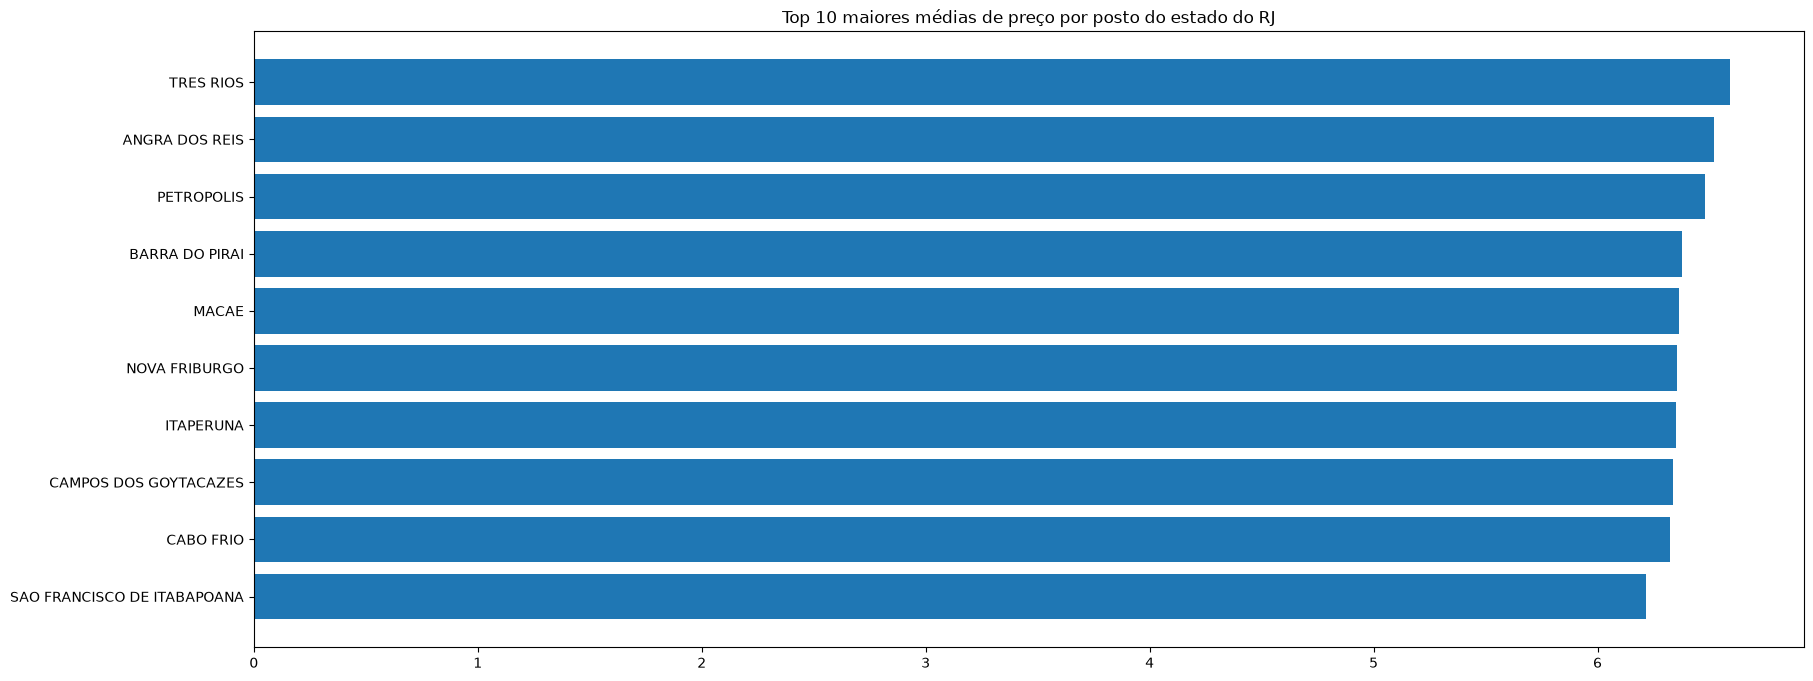

In [205]:
top_10_maiores = df_comun_munics_rj.head(10).sort_values(by='Valor de Venda') # Assim de fato a ordem é crescente
plt.figure(figsize=(20, 8))
plt.barh(top_10_maiores['Municipio'], top_10_maiores['Valor de Venda'])
plt.title('Top 10 maiores médias de preço por posto do estado do RJ')
plt.show()

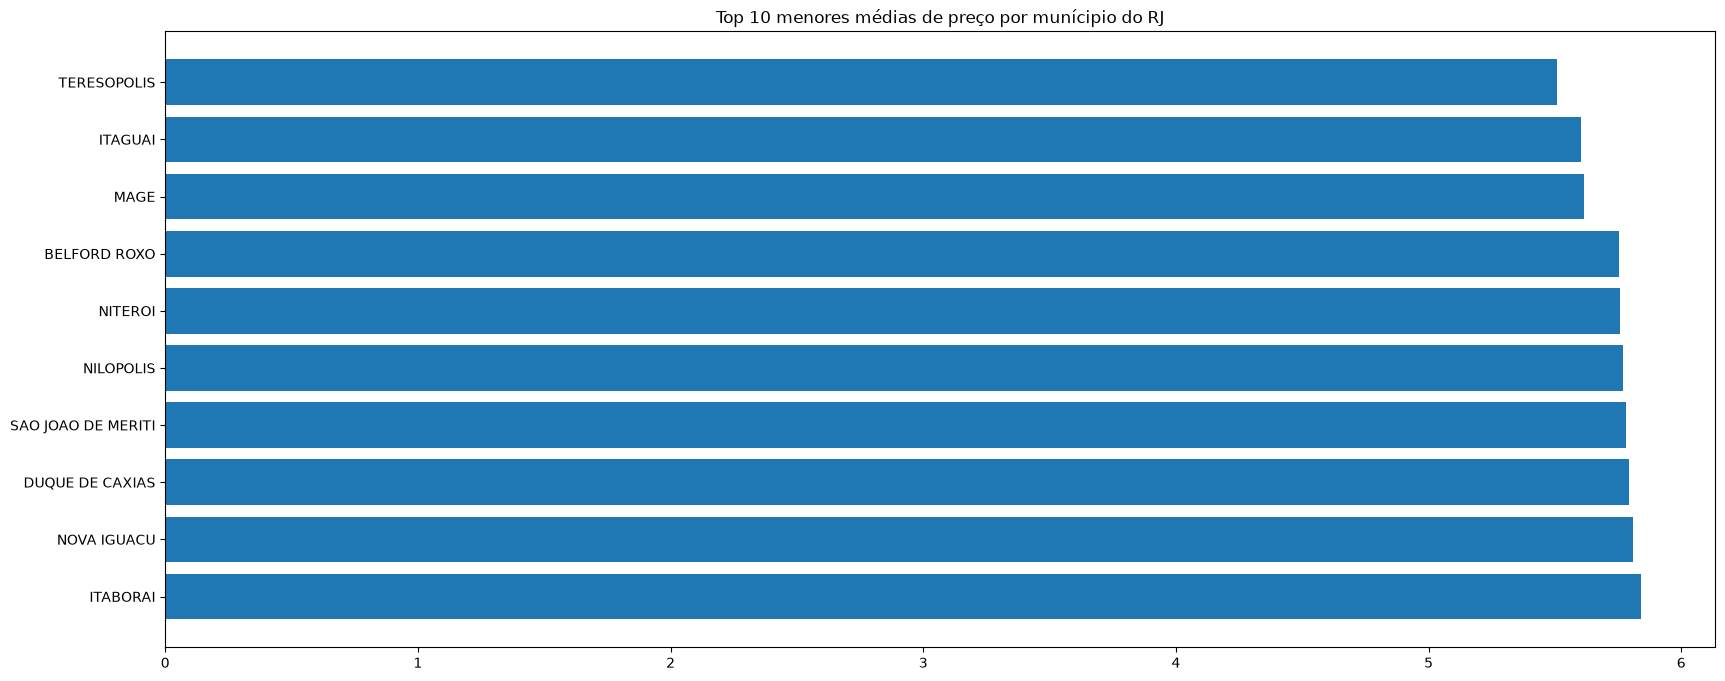

In [152]:
plt.figure(figsize=(20, 8))
plt.barh(df_comun_munics_rj['Municipio'].tail(10), df_comun_munics_rj['Valor de Venda'].tail(10))
plt.title('Top 10 menores médias de preço por munícipio do RJ')
plt.show()

### 3. Outliers no estado do RJ, e estatísticas

In [153]:
df_comun_postos_rj = df_comun_rj_estado.groupby('Revenda')['Valor de Venda'].mean().reset_index().sort_values(by='Valor de Venda', ascending=False)
df_comun_postos_rj

,Revenda,Valor de Venda
690,POSTO JARDIM OCEANICO LTDA.,7.750674
76,AUTO POSTO DE COMBUSTIVEIS M C 2000 DE SANTA I...,7.415000
776,POSTO SATURNO FRIBURGO LTDA,6.824444
1,A C TRANCOZO M B COMBUSTIVEIS LTDA,6.742157
304,COMERCIO DE PETROLEO E DERIVADOS COND DO RIO N...,6.713529
...,...,...
668,POSTO FLAMAREDI EIRELI,5.282000
571,POSTO DE GASOLINA JARDIM SULACAP LTDA,5.226364
569,POSTO DE GASOLINA JAGUAR DO ANIL LTDA,5.156667
567,POSTO DE GASOLINA ITAJUBA LTDA,5.090000


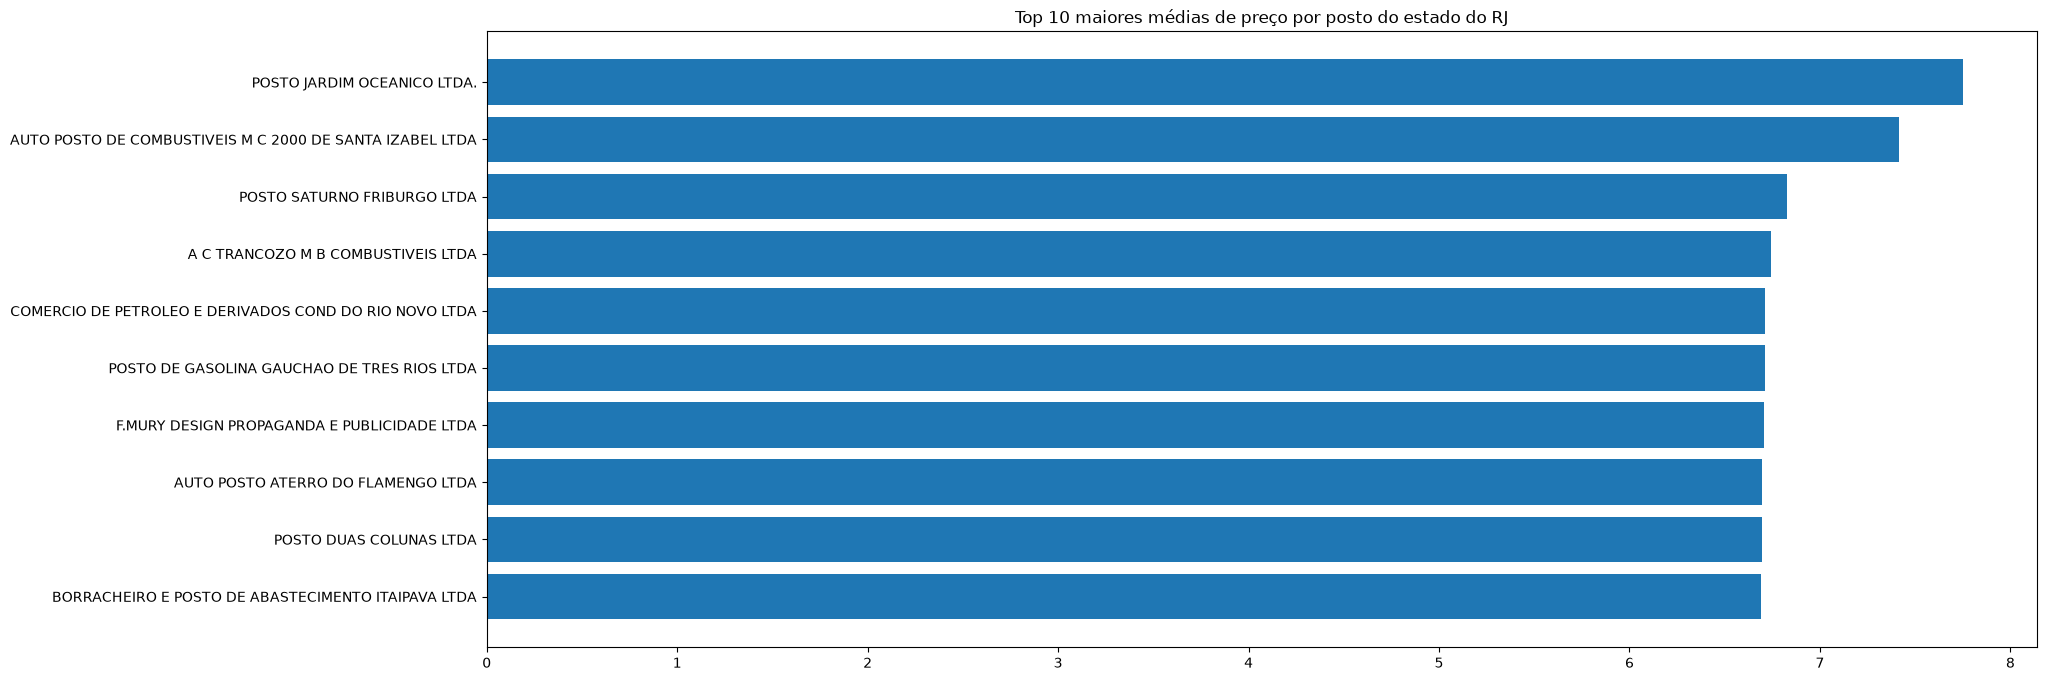

In [ ]:
top_10_maiores = df_comun_postos_rj.head(10).sort_values(by='Valor de Venda')
plt.figure(figsize=(20, 8))
plt.barh(top_10_maiores['Revenda'], top_10_maiores['Valor de Venda'])
plt.title('Top 10 maiores médias de preço por posto do estado do RJ')
plt.show()

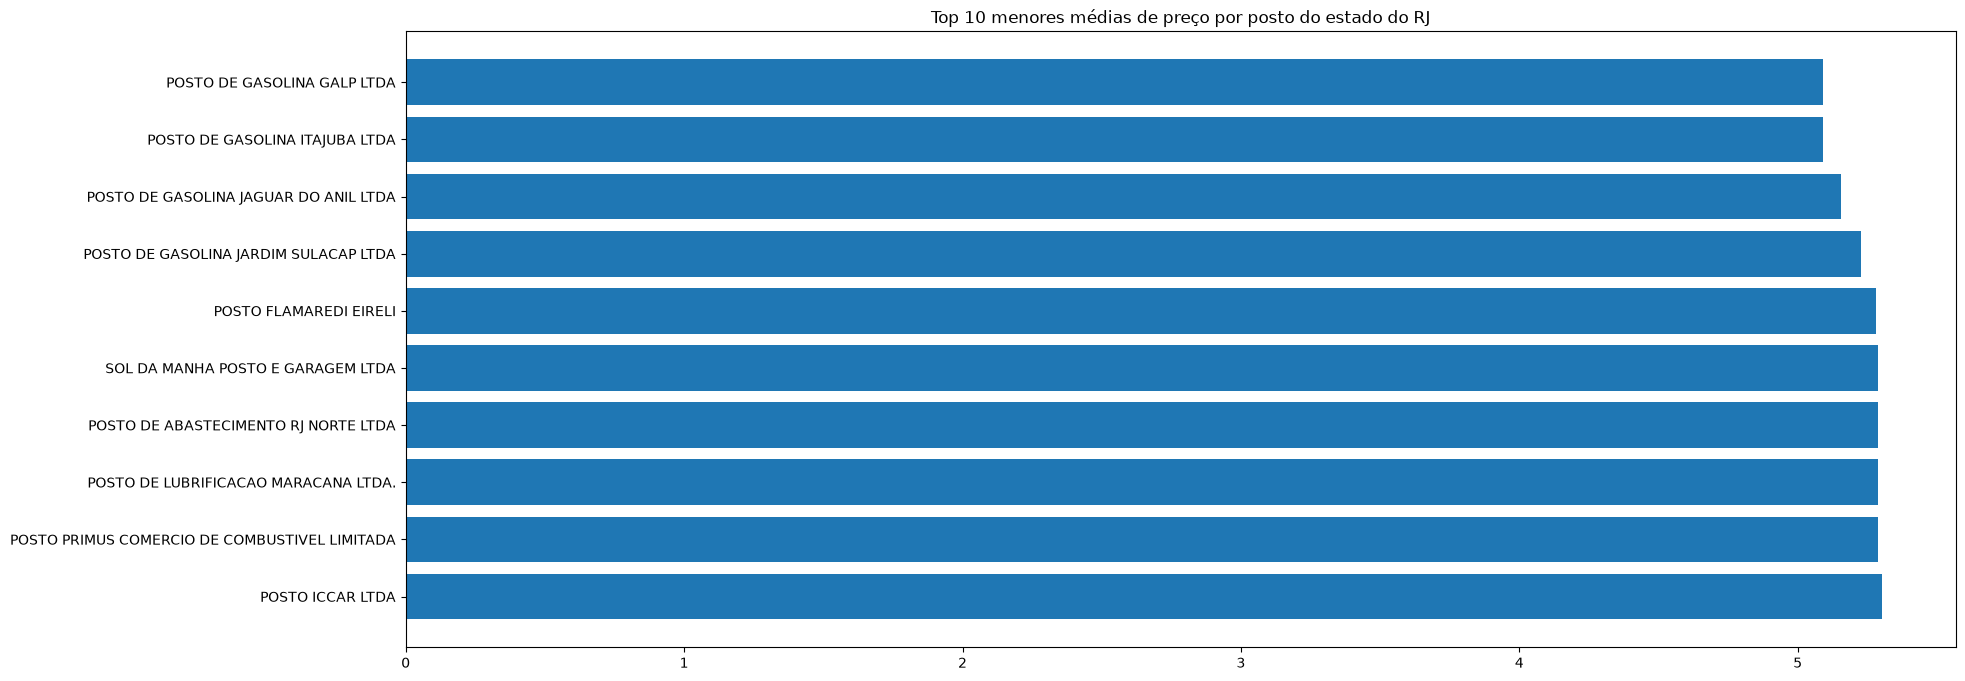

In [155]:
plt.figure(figsize=(20, 8))
plt.barh(df_comun_postos_rj['Revenda'].tail(10), df_comun_postos_rj['Valor de Venda'].tail(10))
plt.title('Top 10 menores médias de preço por posto do estado do RJ')
plt.show()

In [156]:
array_comun_rj = np.array(df_comun_postos_rj['Valor de Venda'])
media_c_rj = np.mean(array_comun_rj)
mediana_c_rj = np.median(array_comun_rj)
q1_c_rj = np.percentile(array_comun_rj, 25)
q3_c_rj = np.percentile(array_comun_rj, 75)
distancia_c_rj = round(((media_c_rj - mediana_c_rj) / mediana_c_rj) * 100, 2)
iqr_c_rj = q3_c_rj - q1_c_rj
l_superior = q3_c_rj + (1.5*iqr_c_rj)
l_inferior = q1_c_rj - (1.5*iqr_c_rj)
print(f'Media: {media_c_rj} \nMediana: {mediana_c_rj} \nDistancia: {distancia_c_rj}% \nQ1: {q1_c_rj} Q3: {q3_c_rj}')
print(f'IQR: {iqr_c_rj} \nSuperior: {l_superior} \nInferior: {l_inferior}')

Media: 5.947818265606212 
Mediana: 5.9136419461502125 
Distancia: 0.58% 
Q1: 5.692154135338346 Q3: 6.19
IQR: 0.49784586466165415 
Superior: 6.936768796992482 
Inferior: 4.945385338345865


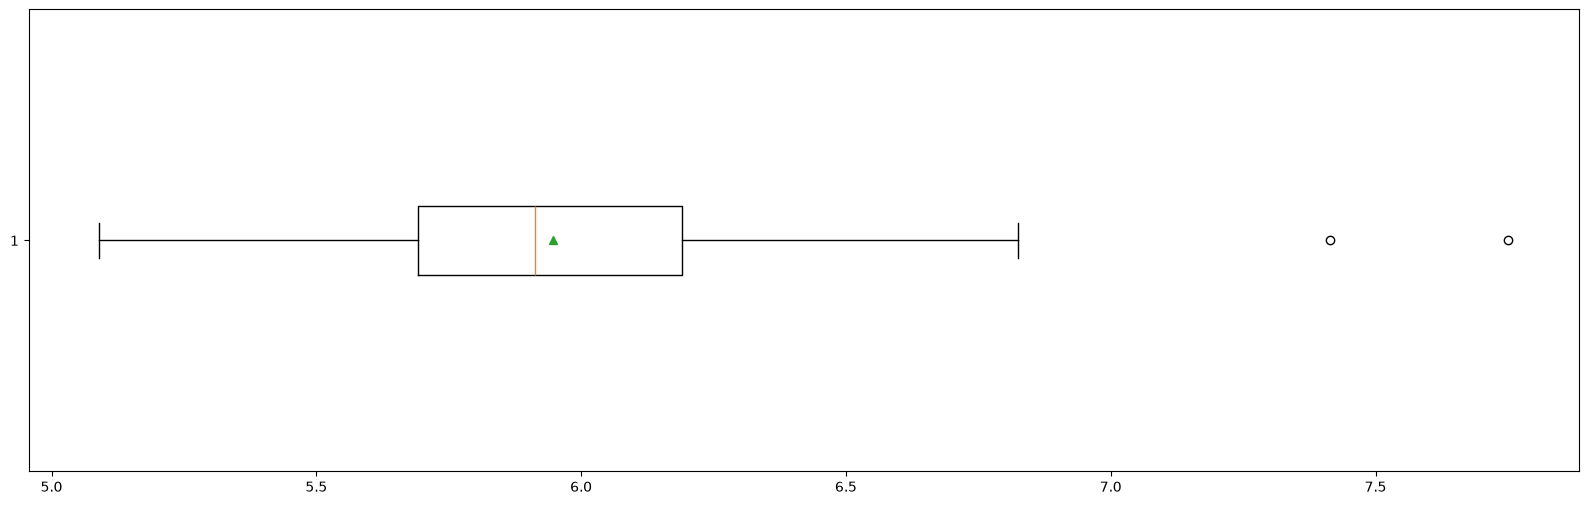

In [208]:
plt.figure(figsize=(20, 6))
plt.boxplot(array_comun_rj, orientation='horizontal', showmeans=True)
plt.show()

O limite inferior não é negativo logo podem existir postos afetando a media

In [158]:
outlier_sup_c_rj = df_comun_postos_rj.loc[df_comun_postos_rj['Valor de Venda'] > l_superior]
outlier_sup_c_rj

,Revenda,Valor de Venda
690,POSTO JARDIM OCEANICO LTDA.,7.750674
76,AUTO POSTO DE COMBUSTIVEIS M C 2000 DE SANTA I...,7.415000


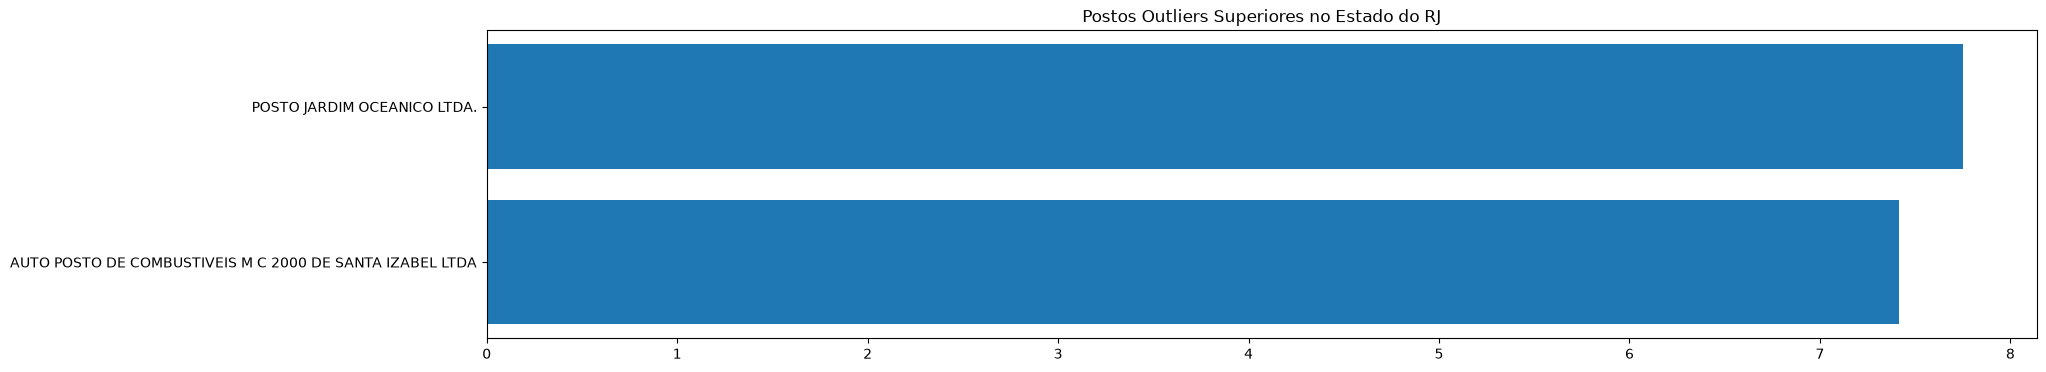

In [159]:
outeliers_sup = outlier_sup_c_rj.sort_values(by='Valor de Venda').head(10) 
plt.figure(figsize=(20, 4))
plt.barh(outeliers_sup['Revenda'], outeliers_sup['Valor de Venda'])
plt.title('Postos Outliers Superiores no Estado do RJ')
plt.show()

In [160]:
outlier_inf_c_rj = df_comun_postos_rj.loc[df_comun_postos_rj['Valor de Venda'] < l_inferior]
outlier_inf_c_rj

,Revenda,Valor de Venda


### 4. Etanol Hidratado 

In [207]:
df_etanol = df.loc[df['Produto'] == 'ETANOL']
df_etanol_rj = df_etanol.loc[df_etanol['Estado - Sigla'] == 'RJ']
df_munic_etanol_rj = df_etanol_rj.groupby('Municipio')['Valor de Venda'].mean().reset_index().sort_values(by='Valor de Venda', ascending=False)
df_etanol_sp = df_etanol.loc[df_etanol['Estado - Sigla'] == 'SP']
df_munic_etanol_sp = df_etanol_sp.groupby('Municipio')['Valor de Venda'].mean().reset_index().sort_values(by='Valor de Venda', ascending=False)

# Jeito facil
df_etanol_sp_rj = df_etanol.groupby('Estado - Sigla')['Valor de Venda'].mean().reset_index().sort_values(by='Valor de Venda', ascending=False)
df_etanol_sp_rj_estado = df_etanol_sp_rj.loc[df_etanol_sp_rj['Estado - Sigla'].isin(['RJ', 'SP'])]
df_etanol_sp_rj_estado

,Estado - Sigla,Valor de Venda
18,RJ,4.434487
25,SP,3.896279


RJ: 

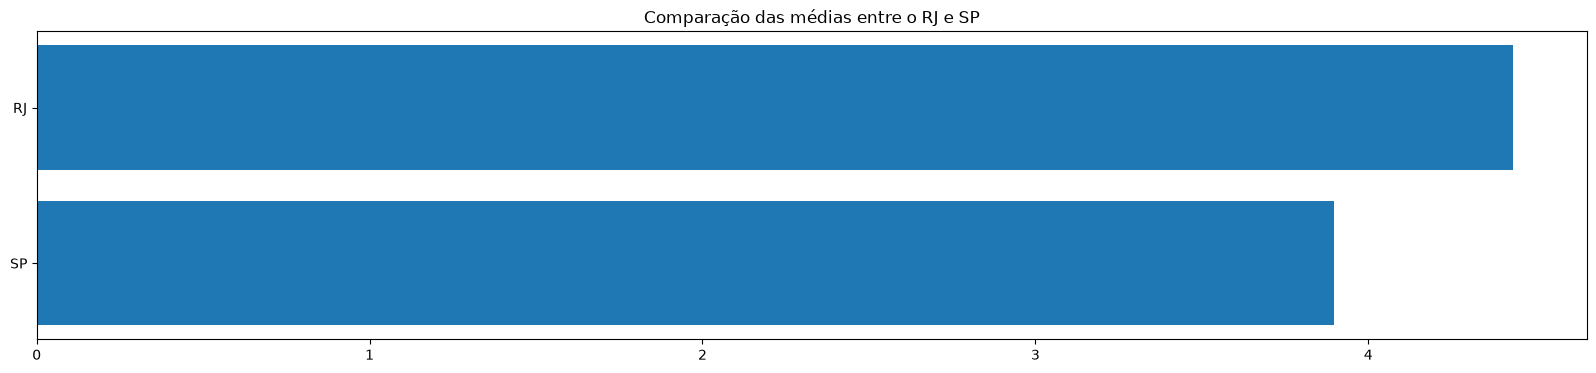

In [162]:
top_10_maiores = df_etanol_sp_rj_estado.sort_values(by='Valor de Venda')
plt.figure(figsize=(20, 4))
plt.barh(top_10_maiores['Estado - Sigla'], top_10_maiores['Valor de Venda'])
plt.title('Comparação das médias entre o RJ e SP')
plt.show()

In [163]:
array_etanol_rj = np.array(df_munic_etanol_rj['Valor de Venda'])
q1_e_rj = np.percentile(array_etanol_rj, 25)
q3_e_rj = np.percentile(array_etanol_rj, 75)
iqr_e_rj = q3_e_rj - q1_e_rj
l_sup_e_rj = q3_e_rj + (1.5*iqr_e_rj)
l_inf_e_rj = q1_e_rj - (1.5*iqr_e_rj)

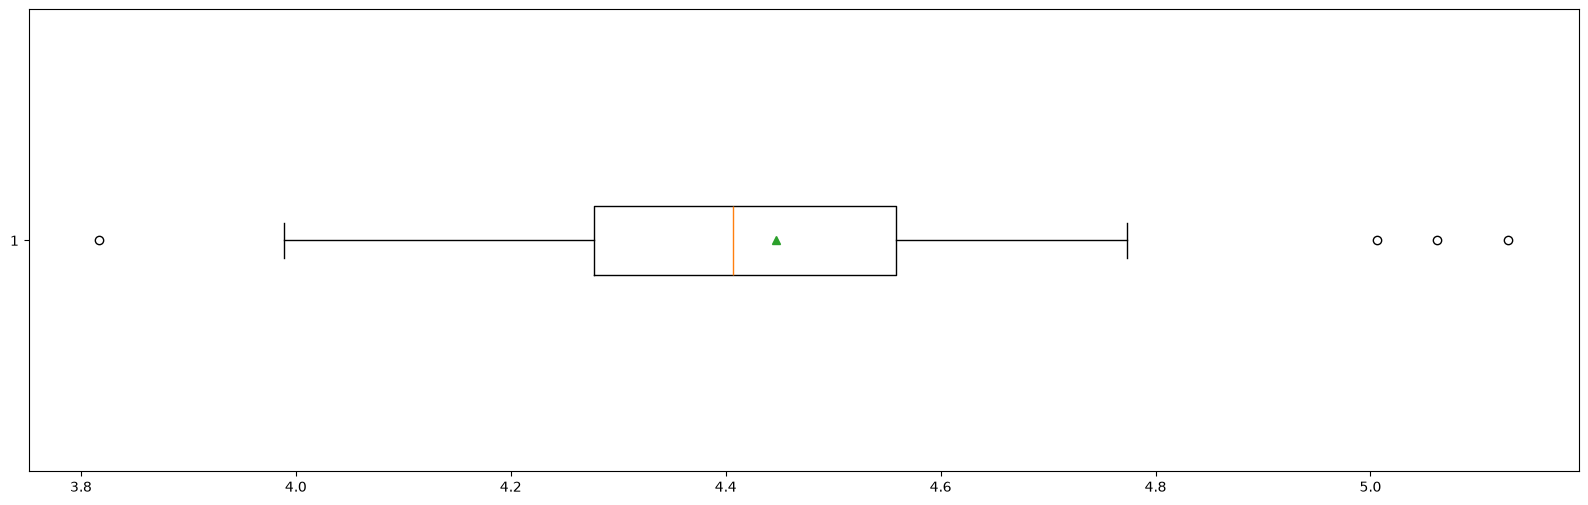

In [164]:
plt.figure(figsize=(20, 6))
plt.boxplot(array_etanol_rj, orientation='horizontal', showmeans=True)
plt.show()

In [165]:
outlier_sup_e_rj = df_munic_etanol_rj.loc[df_munic_etanol_rj['Valor de Venda'] > l_sup_e_rj]
outlier_sup_e_rj

,Municipio,Valor de Venda
29,TRES RIOS,5.128235
18,PETROPOLIS,5.062155
0,ANGRA DOS REIS,5.005747


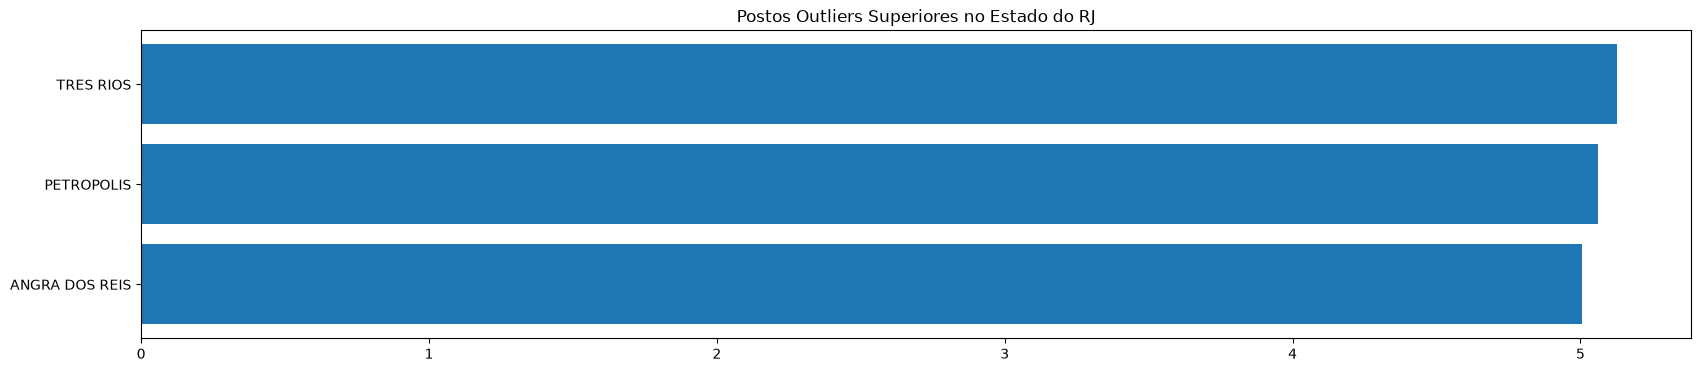

In [ ]:
outeliers_sup = outlier_sup_e_rj.sort_values(by='Valor de Venda').head(10) 
plt.figure(figsize=(20, 4))
plt.barh(outeliers_sup['Municipio'], outeliers_sup['Valor de Venda'])
plt.title('Municipios Outliers Superiores no Estado do RJ')
plt.show()

In [167]:
outlier_inf_e_rj = df_munic_etanol_rj.loc[df_munic_etanol_rj['Valor de Venda'] < l_inf_e_rj]
outlier_inf_e_rj

,Municipio,Valor de Venda
28,TERESOPOLIS,3.816982


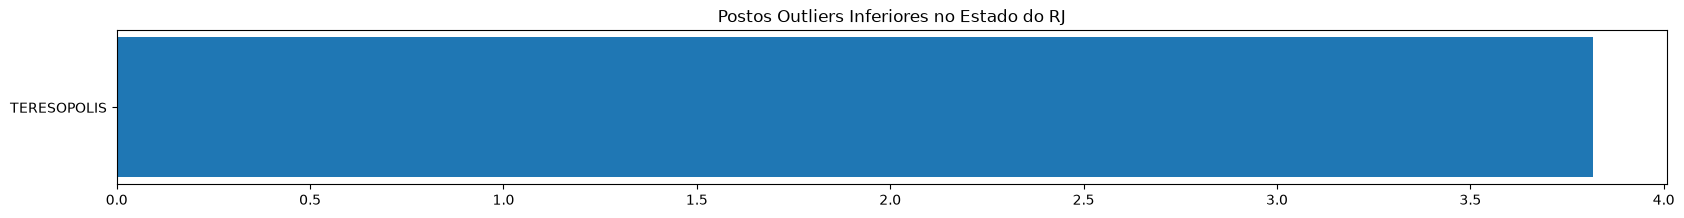

In [ ]:
plt.figure(figsize=(20, 2))
plt.barh(outlier_inf_e_rj['Municipio'].tail(10), outlier_inf_e_rj['Valor de Venda'].tail(10))
plt.title('Municipios Outliers Inferiores no Estado do RJ')
plt.show()

SP:

In [169]:
array_etanol_sp = np.array(df_munic_etanol_sp['Valor de Venda'])
q1_e_sp = np.percentile(array_etanol_sp, 25)
q3_e_sp = np.percentile(array_etanol_sp, 75)
iqr_e_sp = q3_e_sp - q1_e_sp
l_sup_e_sp = q3_e_sp + (1.5*iqr_e_sp)
l_inf_e_sp = q1_e_sp - (1.5*iqr_e_sp)

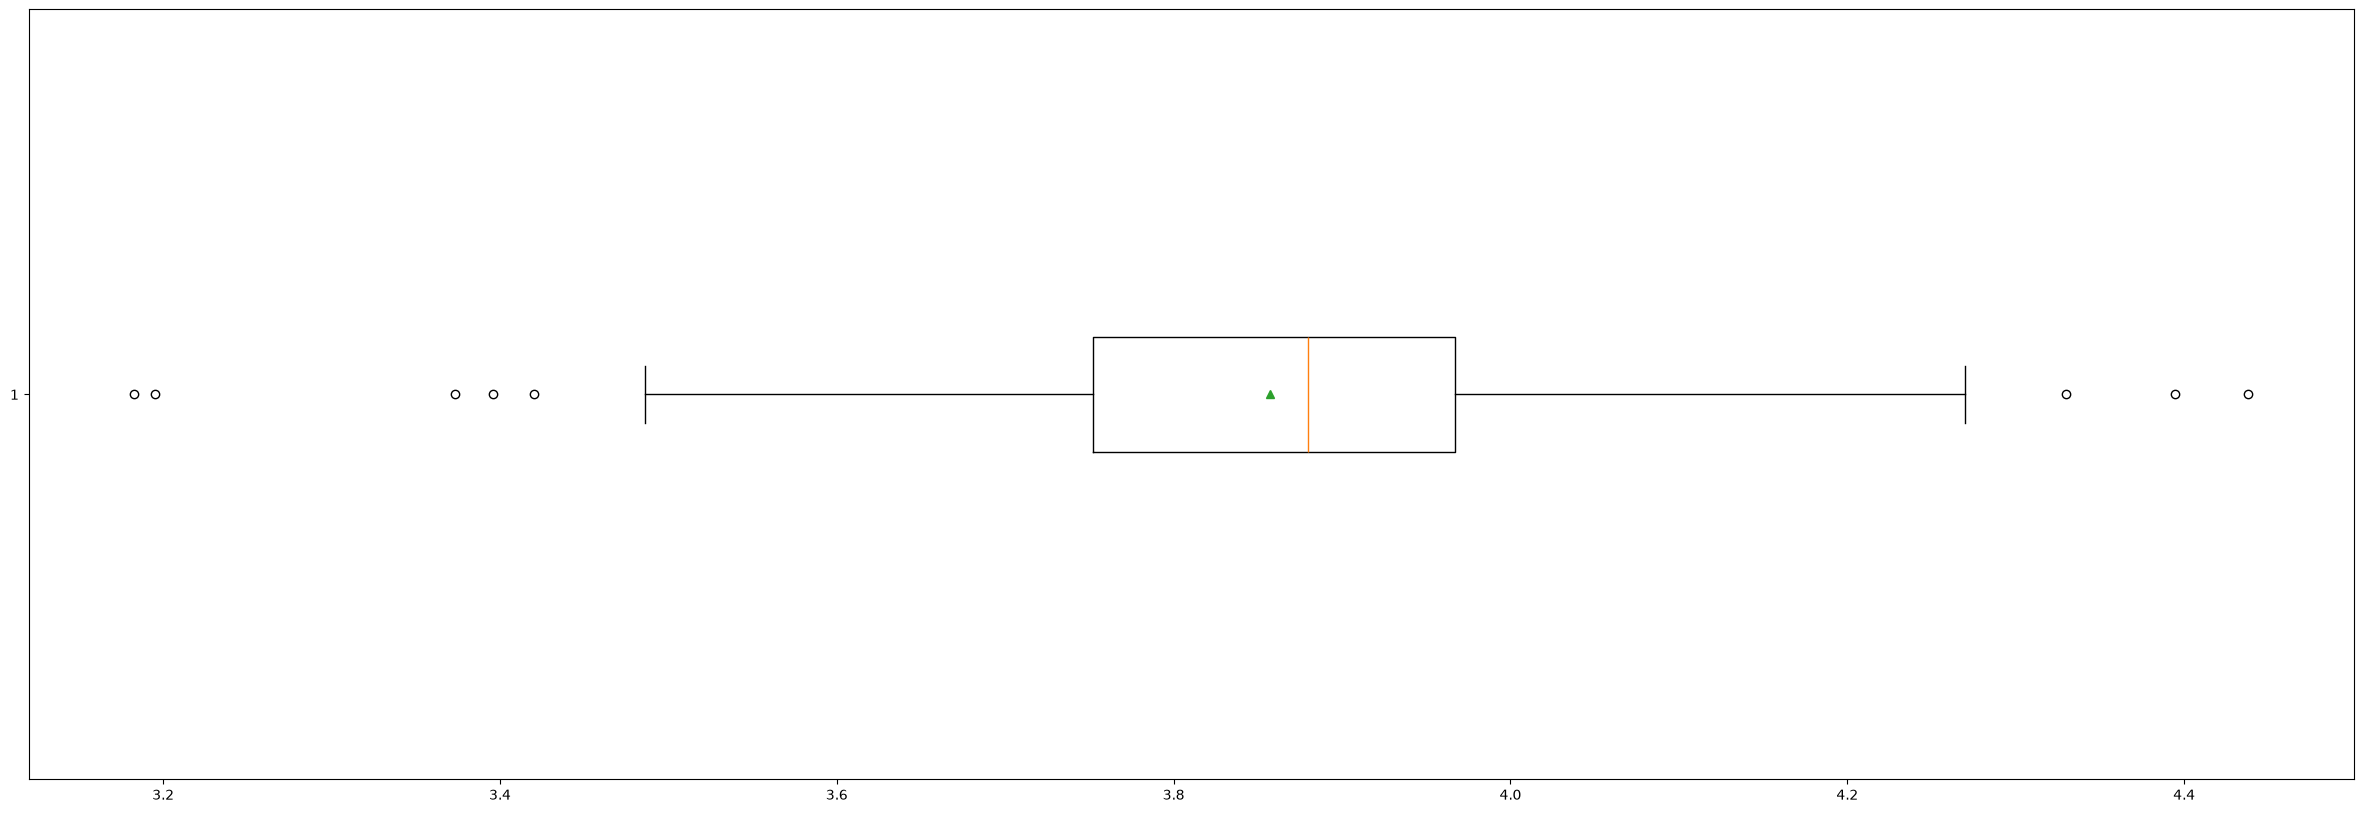

In [209]:
plt.figure(figsize=(30, 10))
plt.boxplot(array_etanol_sp, orientation='horizontal', showmeans=True)
plt.show()

In [171]:
outlier_sup_e_sp = df_munic_etanol_sp.loc[df_munic_etanol_sp['Valor de Venda'] > l_sup_e_sp]
outlier_sup_e_sp

,Municipio,Valor de Venda
10,BARUERI,4.437937
24,CUBATAO,4.394575
31,GUARUJA,4.329950


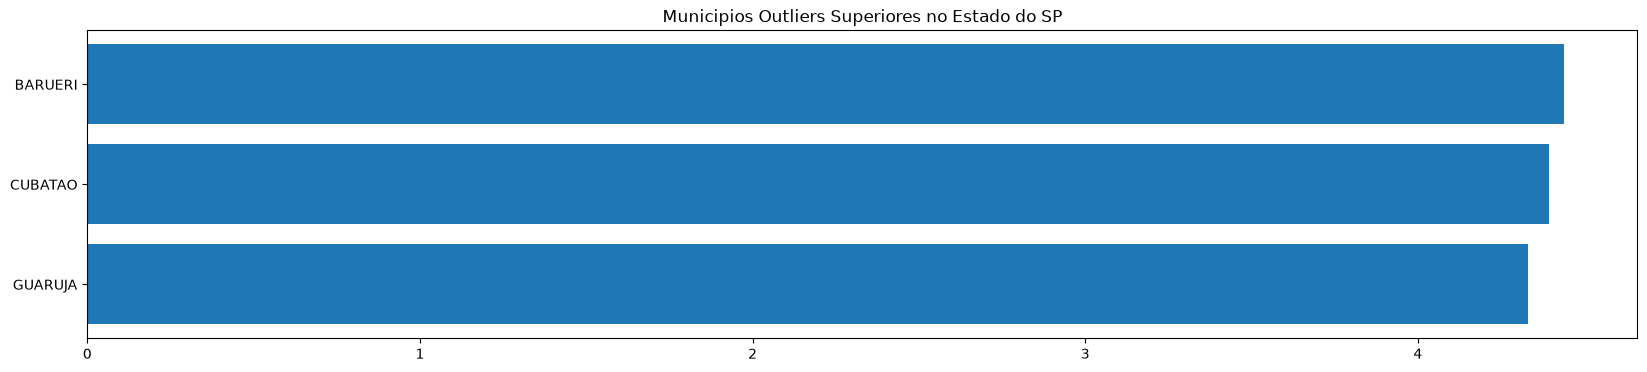

In [185]:
outeliers_sup = outlier_sup_e_sp.sort_values(by='Valor de Venda').head(10) 
plt.figure(figsize=(20, 4))
plt.barh(outeliers_sup['Municipio'], outeliers_sup['Valor de Venda'])
plt.title('Municipios Outliers Superiores no Estado do SP')
plt.show()

In [172]:
outlier_inf_e_sp = df_munic_etanol_sp.loc[df_munic_etanol_sp['Valor de Venda'] < l_inf_e_sp]
outlier_inf_e_sp

,Municipio,Valor de Venda
26,DRACENA,3.420116
92,SAO ROQUE,3.396087
81,SANTA BARBARA D'OESTE,3.373045
58,MIRASSOL,3.194895
76,PRESIDENTE VENCESLAU,3.182949


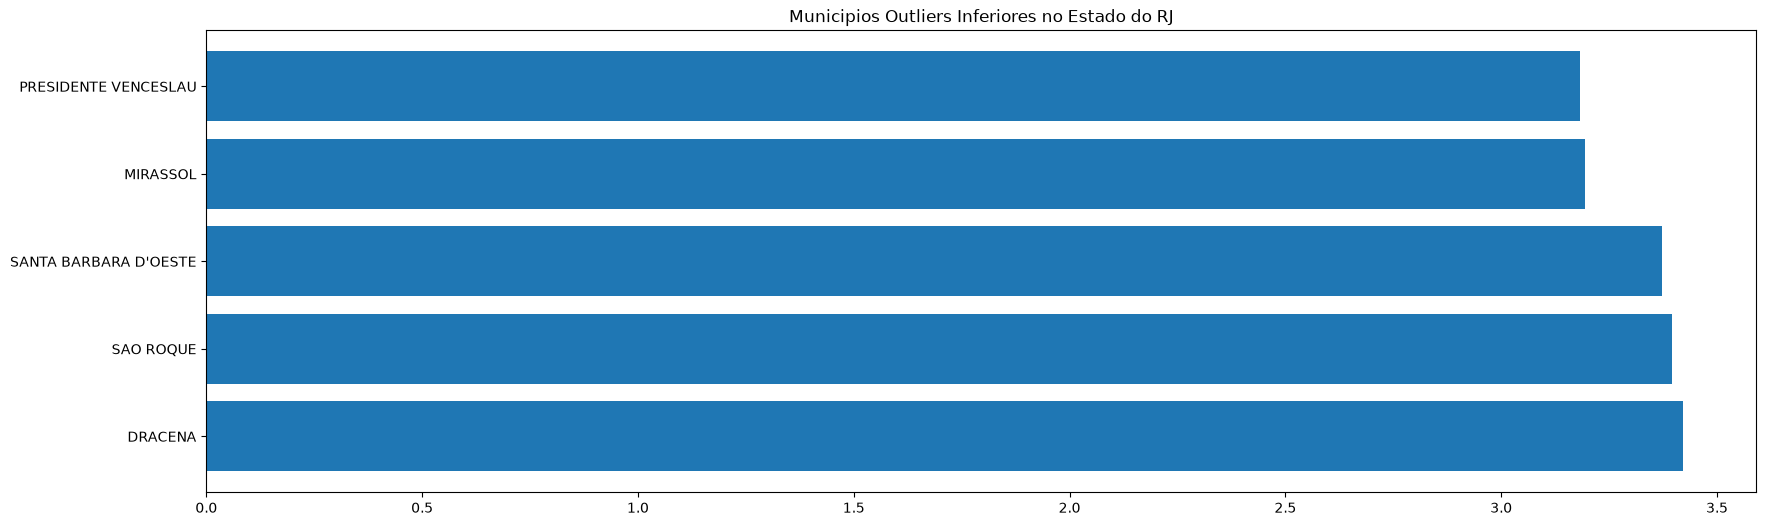

In [188]:
plt.figure(figsize=(20, 6))
plt.barh(outlier_inf_e_sp['Municipio'].tail(10), outlier_inf_e_sp['Valor de Venda'].tail(10))
plt.title('Municipios Outliers Inferiores no Estado do RJ')
plt.show()

In [173]:
print('Dados RJ:')
print(f'Q1: {q1_e_rj} Q3: {q3_e_rj}')
print(f'IQR: {iqr_e_rj} \nSuperior: {l_sup_e_rj} Inferior: {l_inf_e_rj}')
print('Dados SP:')
print(f'Q1: {q1_e_sp} Q3: {q3_e_sp}')
print(f'IQR: {iqr_e_sp} \nSuperior: {l_sup_e_sp} Inferior: {l_inf_e_sp}')
round(df_etanol_sp_rj_estado, 2)

Dados RJ:
Q1: 4.27764986189478 Q3: 4.558372256933862
IQR: 0.28072239503908225 
Superior: 4.979455849492485 Inferior: 3.8565662693361564
Dados SP:
Q1: 3.7518841150359172 Q3: 3.9669126446587217
IQR: 0.2150285296228045 
Superior: 4.2894554390929285 Inferior: 3.4293413206017105


,Estado - Sigla,Valor de Venda
18,RJ,4.43
25,SP,3.90


Conclusão, as estáticas são parecidas, mas ainda são um pouco distantes.

### 5. Preço da gasolina em bairros do rj municipio:

In [174]:
df_comun_rj_cap = df_comun.loc[df_comun['Municipio'] == 'RIO DE JANEIRO']
df_comun_rj_bairro = df_comun_rj_cap.groupby('Bairro')['Valor de Venda'].mean().reset_index().sort_values(by='Valor de Venda', ascending=False)

O preços mais caros estão divididos entre os bairros centrais

In [175]:
df_comun_rj_bairro.head(10)

,Bairro,Valor de Venda
23,FLAMENGO,6.696667
41,JARDIM BOTANICO,6.614615
44,LAGOA,6.505385
55,PARQUE FLAMENGO,6.454706
21,ESTACIO,6.416882
33,IPANEMA,6.291923
30,GÁVEA,6.290000
26,GAVEA,6.290000
79,VARGEM PEQUENA,6.266140
45,LARANJEIRAS,6.237361


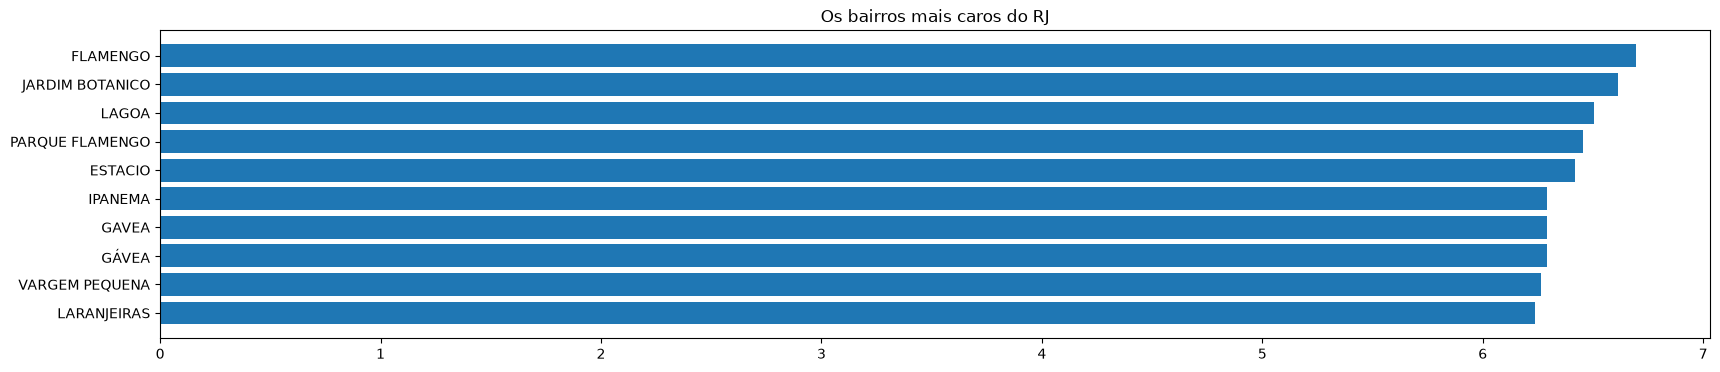

In [198]:
bairros_caros = df_comun_rj_bairro.head(10).sort_values(by='Valor de Venda')
plt.figure(figsize=(20, 4))
plt.barh(bairros_caros['Bairro'], bairros_caros['Valor de Venda'])
plt.title('Os bairros mais caros do RJ')
plt.show()

Os preços mais baratos são em bairros perifericos

In [176]:
df_comun_rj_bairro.tail(10)

,Bairro,Valor de Venda
47,MADUREIRA,5.442941
2,ANDARAÍ,5.440000
34,IRAJA,5.423333
62,QUINTINO BOCAIUVA,5.409565
68,ROCHA,5.375854
50,MEIER,5.340000
37,JACARE,5.310000
49,MARIA DA GRACA,5.290000
43,JARDIM SULACAP,5.226364
3,ANIL,5.156667


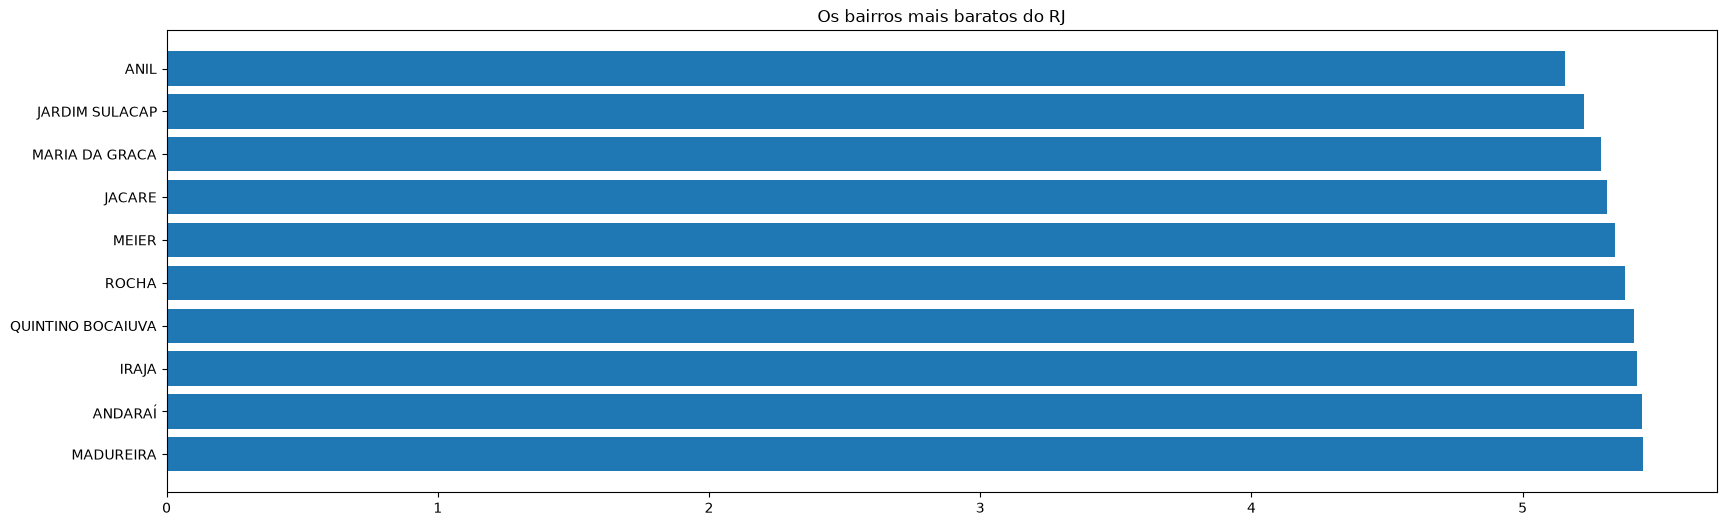

In [199]:
plt.figure(figsize=(20, 6))
plt.barh(df_comun_rj_bairro['Bairro'].tail(10), df_comun_rj_bairro['Valor de Venda'].tail(10))
plt.title('Os bairros mais baratos do RJ')
plt.show()

In [177]:
array_c_rj_bairro = np.array(df_comun_rj_bairro['Valor de Venda'])
q1_c_rj_bairro = np.percentile(array_c_rj_bairro, 25)
q3_c_rj_bairro = np.percentile(array_c_rj_bairro, 75)
iqr_c_rj_bairro = q3_c_rj_bairro - q1_c_rj_bairro
l_sup_c_rj_bairro = q3_c_rj_bairro + (1.5*iqr_c_rj_bairro)
l_inf_c_rj_bairro = q1_c_rj_bairro - (1.5*iqr_c_rj_bairro)
print(f'Q1: {q1_c_rj_bairro} Q3: {q3_c_rj_bairro}')
print(f'IQR: {iqr_c_rj_bairro} \nSuperior: {l_sup_c_rj_bairro} \nInferior: {l_inf_c_rj_bairro}')

Q1: 5.640000000000001 Q3: 6.060588235294118
IQR: 0.42058823529411704 
Superior: 6.691470588235293 
Inferior: 5.009117647058825


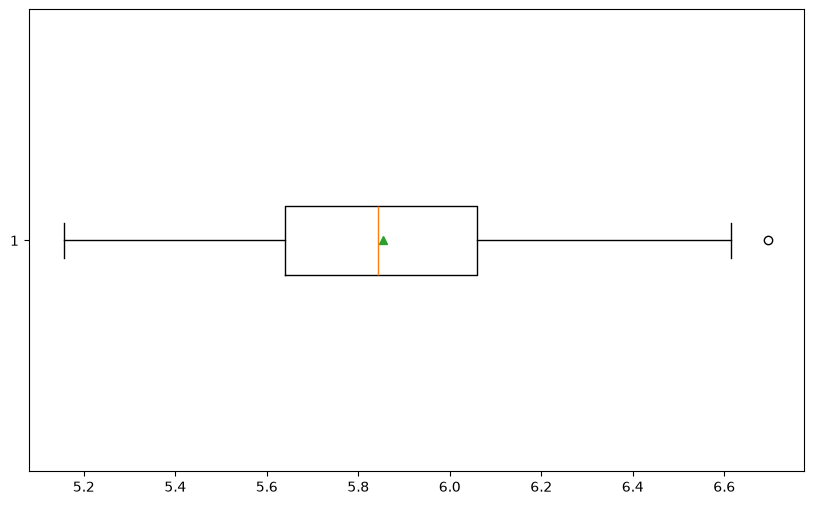

In [178]:
plt.figure(figsize=(10, 6))
plt.boxplot(array_c_rj_bairro, orientation='horizontal', showmeans=True)
plt.show()

O unico outlier superior é o Flamengo

In [179]:
outlier_sup_c_rj_bairros = df_comun_rj_bairro.loc[df_comun_rj_bairro['Valor de Venda'] > l_sup_c_rj_bairro]
outlier_sup_c_rj_bairros

,Bairro,Valor de Venda
23,FLAMENGO,6.696667


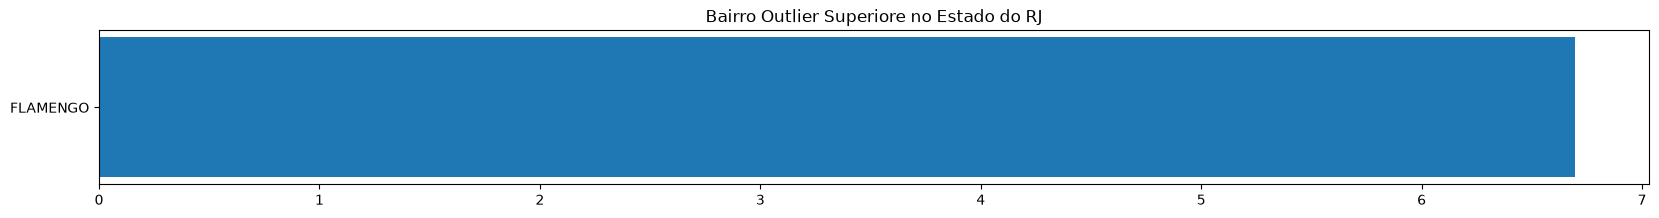

In [202]:
outeliers_sup = outlier_sup_c_rj_bairros.sort_values(by='Valor de Venda').head(10) 
plt.figure(figsize=(20, 2))
plt.barh(outeliers_sup['Bairro'], outeliers_sup['Valor de Venda'])
plt.title('Bairro Outlier Superiore no Estado do RJ')
plt.show()

O preço mais baixo é o Anil e ele está superior ao limite inferior, logo não faz diferença na media 

In [180]:
outlier_inf_c_rj_bairros = df_comun_rj_bairro.loc[df_comun_rj_bairro['Valor de Venda'] < l_inf_c_rj_bairro]
outlier_inf_c_rj_bairros

,Bairro,Valor de Venda


# Aula 6 aprendendo os graficos

In [181]:
df_comun_rj_cap['Data da Coleta'] = pd.to_datetime(df_comun_rj_cap['Data da Coleta'], dayfirst=True)

In [182]:
# plt.figure(figsize=(9, 27))
# plt.barh(df_comun_rj_bairro['Bairro'], df_comun_rj_bairro['Valor de Venda'])
# plt.title('Preço entre os bairros do RJ')
# plt.show()

df_comun_rj_temp = df_comun_rj_cap.groupby('Data da Coleta')['Valor de Venda'].mean().reset_index()
df_comun_rj_temp

,Data da Coleta,Valor de Venda
0,2024-01-02,5.452037
1,2024-01-03,5.717778
2,2024-01-08,5.438788
3,2024-01-09,5.498485
4,2024-01-10,5.370000
...,...,...
254,2025-12-15,6.037838
255,2025-12-16,5.866667
256,2025-12-22,6.024810
257,2025-12-23,5.923333


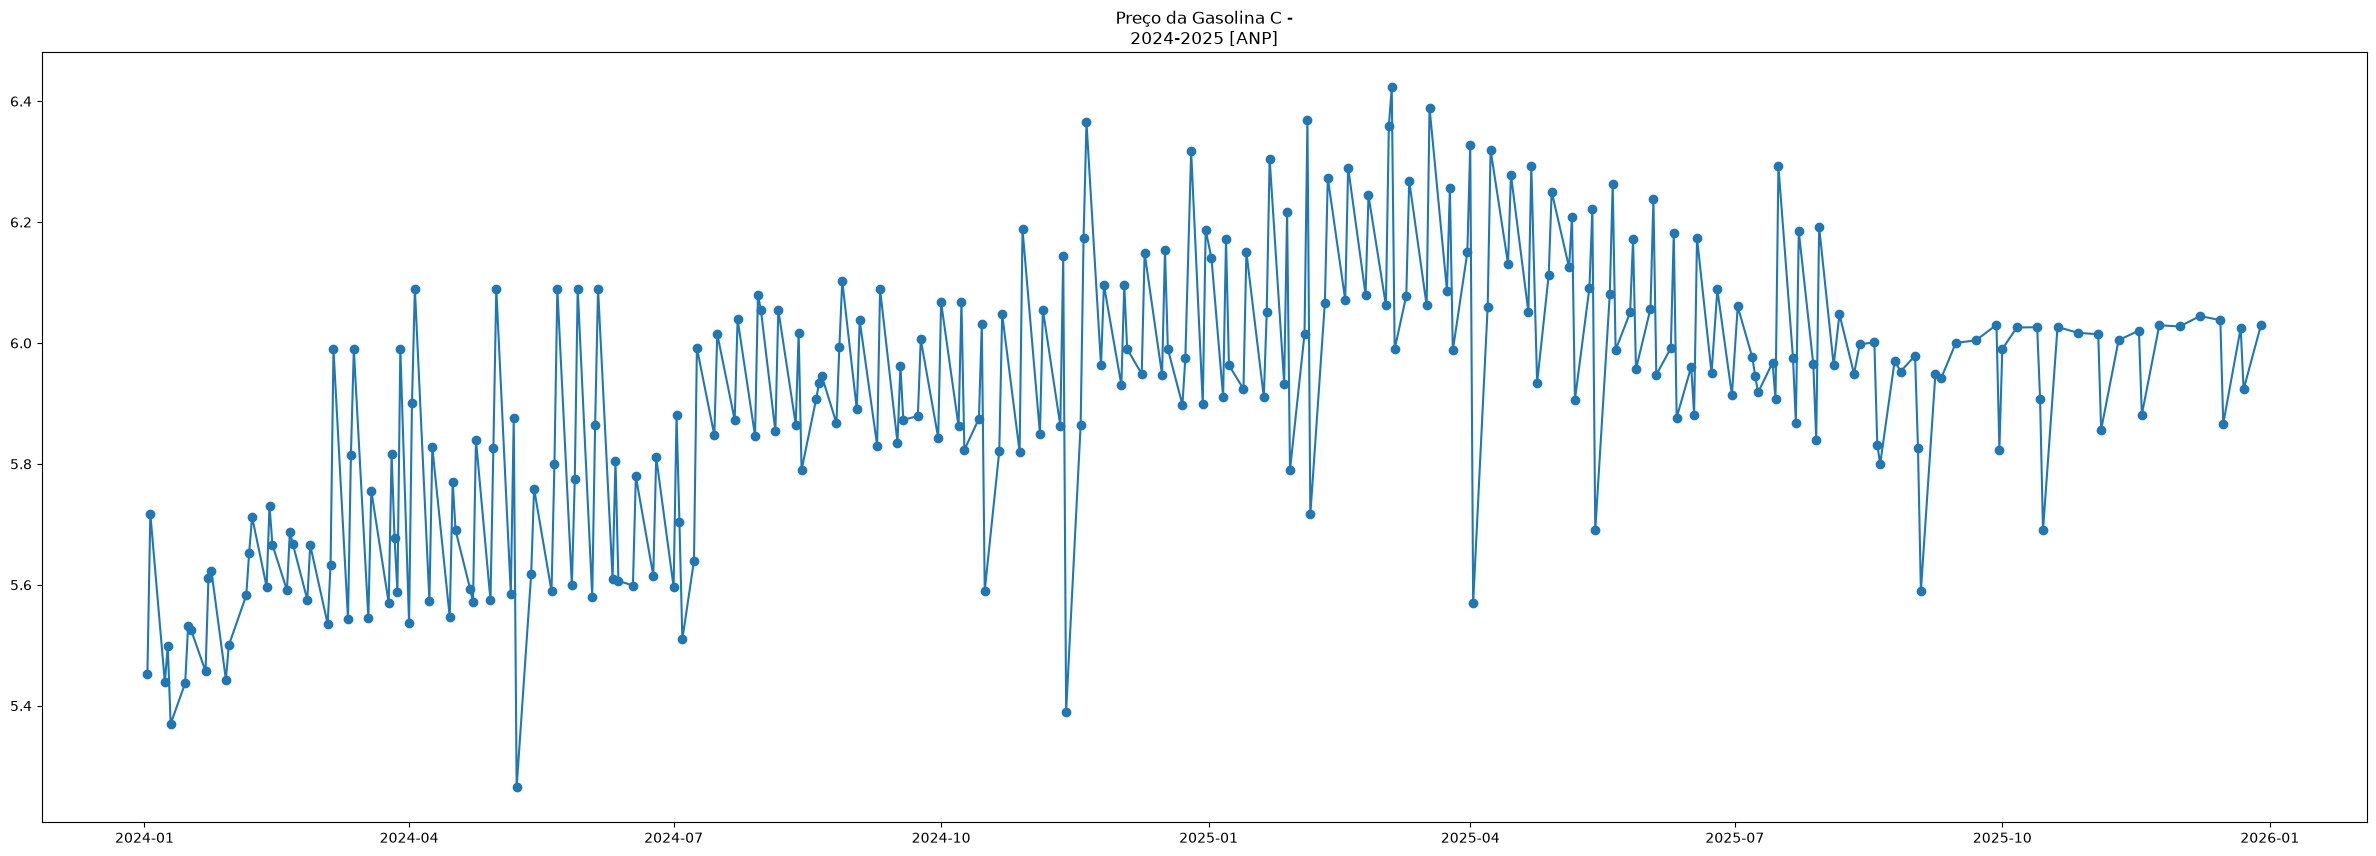

In [183]:
plt.figure(figsize=(30,10))
plt.plot(df_comun_rj_temp['Data da Coleta'], df_comun_rj_temp['Valor de Venda'], marker='o')
plt.title('Preço da Gasolina C -\n2024-2025 [ANP]')
plt.show()